In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from pydantic import BaseModel, Field
import operator

In [2]:
load_dotenv()

False

In [ ]:
import os
from langchain_groq import ChatGroq

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY", "")

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [4]:
response = model.invoke("hello")

print(response.content)

Hello. How can I assist you today?


In [5]:
class evaluation_schema(BaseModel):
    feedback: str = Field(description = 'Feedback about the essay')
    score: int = Field(description = 'Score out of 10', ge=0, le=10)

In [6]:
struct_model = model.with_structured_output(evaluation_schema)

In [7]:
essay = """
In the heart of the bustling city, there was a small park that served as a sanctuary for
the weary souls. The park was adorned with vibrant flowers, towering trees, and a serene pond that reflected the sky like a mirror. People from all walks of life would come to the park to find solace and escape the chaos of the city.
One sunny afternoon, a young girl named Lily came to the park with her friends. They sat by the pond, enjoying the peaceful atmosphere and the beautiful scenery around them.
As they were chatting and laughing, a gentle breeze swept through the park, carrying with it the sweet scent of blooming flowers. Lily closed her eyes and took a deep breath, feeling the tranquility wash over her.
In that moment, she realized how important it was to have a place like this in the midst of the city. The park was not just a physical space, but a refuge for the mind and soul. It reminded her that even in the busiest of places, there is always a sanctuary to be found if one takes the time to look for it.
"""

In [8]:
prompt = f"Evaluate the following essay and provide feedback and a score out of 10:\n\n{essay}"
struct_model.invoke(prompt)

evaluation_schema(feedback="The essay is well-written and effectively transports the reader to a serene and peaceful environment. The use of descriptive language, such as 'vibrant flowers', 'towering trees', and 'serene pond', helps to create a vivid image in the reader's mind. The story is also relatable and conveys a meaningful message about the importance of finding solace in nature. However, the essay could benefit from more complex sentence structures and a clearer thesis statement. Additionally, the character development is limited, and the story is somewhat predictable.", score=8)

In [9]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[int], operator.add]
    average_score: float

In [10]:
def evaluate_language(state: UPSCState) -> UPSCState:
    prompt = f"Evaluate the language used in the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = struct_model.invoke(prompt)

    return {'language_feedback': result.feedback, 'individual_scores': [result.score]}

In [11]:
def evaluate_analysis(state: UPSCState) -> UPSCState:
    prompt = f"Evaluate the analysis provided in the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = struct_model.invoke(prompt)
    
    return {'analysis_feedback': result.feedback, 'individual_scores': [result.score]}

In [12]:
def evaluate_clarity(state: UPSCState) -> UPSCState:
    prompt = f"Evaluate the clarity of the following essay and provide feedback and a score out of 10:\n\n{state['essay']}"
    result = struct_model.invoke(prompt)
    
    return {'clarity_feedback': result.feedback, 'individual_scores': [result.score]}

In [13]:
def final_evaluation(state: UPSCState) -> UPSCState:
    average_score = sum(state['individual_scores']) / len(state['individual_scores'])
    overall_feedback = f"Overall, the essay scored an average of {average_score:.2f} out of 10. The language was {state['language_feedback']}, the analysis was {state['analysis_feedback']}, and the clarity was {state['clarity_feedback']}."
    
    return {'overall_feedback': overall_feedback, 'average_score': average_score}

In [14]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_clarity', evaluate_clarity)
graph.add_node('final_evaluation', final_evaluation)

graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_clarity')
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_clarity', 'final_evaluation')
graph.add_edge('final_evaluation', END)

workflow = graph.compile()

In [15]:
initial_state = {
    'essay': essay
}

workflow.invoke(initial_state)

{'essay': '\nIn the heart of the bustling city, there was a small park that served as a sanctuary for\nthe weary souls. The park was adorned with vibrant flowers, towering trees, and a serene pond that reflected the sky like a mirror. People from all walks of life would come to the park to find solace and escape the chaos of the city.\nOne sunny afternoon, a young girl named Lily came to the park with her friends. They sat by the pond, enjoying the peaceful atmosphere and the beautiful scenery around them.\nAs they were chatting and laughing, a gentle breeze swept through the park, carrying with it the sweet scent of blooming flowers. Lily closed her eyes and took a deep breath, feeling the tranquility wash over her.\nIn that moment, she realized how important it was to have a place like this in the midst of the city. The park was not just a physical space, but a refuge for the mind and soul. It reminded her that even in the busiest of places, there is always a sanctuary to be found if

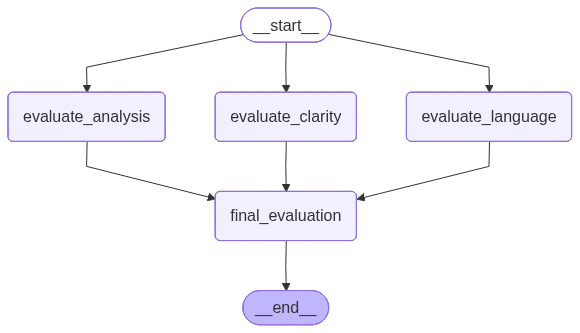

In [16]:
workflow